In [88]:
#Mathematics and ML
import torch

#Project package
from graphtools.graphon import sample_positions
from graphtools import builder

#Autoreload module
"""
These magic lines allow to automatically reload any module.py file when there are some changes on it, without the needing of restart the kernel anytime a new change is applied to the module script
"""
%load_ext autoreload
%autoreload 2

# Positions are created directly on the selected device; build_graph inherits it.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
#Generate positions
n = 50
position_type = "ring"
positions = sample_positions(n = n, device = device, position_type = position_type)

In [90]:
#Generate Voronoi edges
params = {
    "method" : "voronoi",
    "add_voronoi" : True,
}
graph = builder.build_graph(positions, **params)

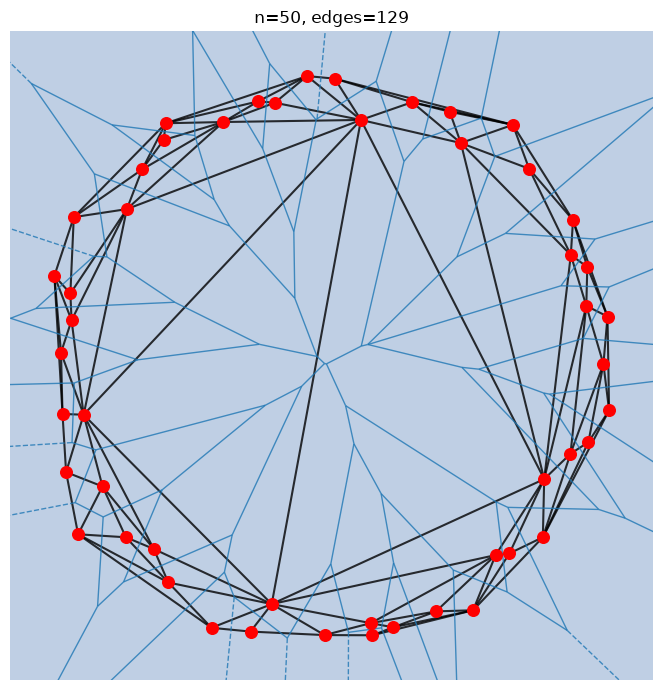

In [91]:
#Plot positions over the Voronoi cells
builder.plot_nodes(graph, voronoi = True)

In [92]:
# Generate epsilon-Voronoi edges
method_kwargs = {
    "epsilon": 0.3,
    "tolerance": 1e-9,
    "resolution": 32,
}
params = {
    "method" : "epsilon_voronoi",
    "add_voronoi" : True,
    "method_kwargs" : method_kwargs,
}
graph = builder.build_graph(positions, **params)

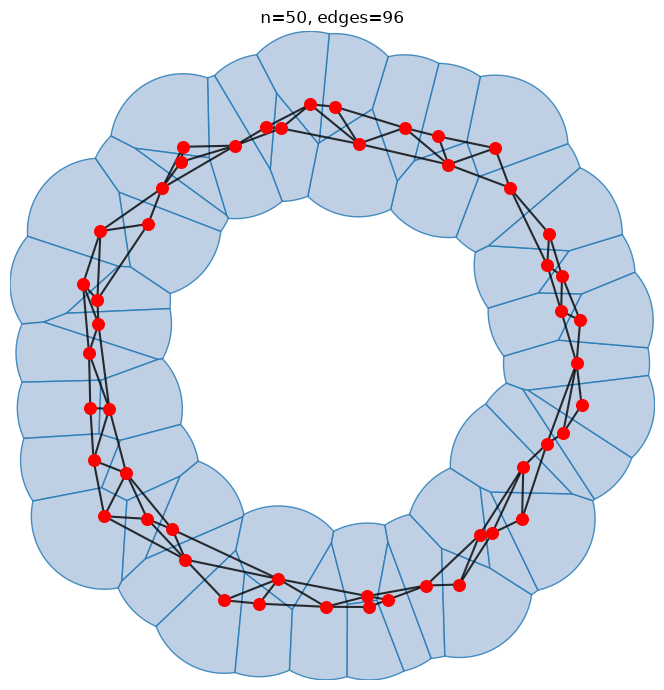

In [93]:
#Plot positions over the epsilon-Voronoi cells
builder.plot_nodes(graph, voronoi = True)